In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, f1_score

In [13]:
merged_pokemon = pd.read_csv("pokemon/data/modified/merged_pokemon.csv")
combats = pd.read_csv("pokemon/data/raw_data/combats.csv")

In [14]:
dirty_data = pd.merge(combats, merged_pokemon, left_on='First_pokemon', right_on='ID', how='inner')
dirty_data.drop(columns=['ID'], inplace=True)
dirty_data.rename(columns={c: f"{c}_P1" for c in dirty_data.columns[3:]}, inplace=True)

dirty_data = pd.merge(dirty_data, merged_pokemon, left_on='Second_pokemon', right_on='ID', how='inner')
dirty_data.drop(columns=['ID'], inplace=True)
dirty_data.rename(columns={c: f"{c}_P2" for c in dirty_data.columns[3 + merged_pokemon.shape[1] - 1:]}, inplace=True)

df = dirty_data.copy()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 97 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   First_pokemon          50000 non-null  int64  
 1   Second_pokemon         50000 non-null  int64  
 2   Winner                 50000 non-null  int64  
 3   Name_P1                50000 non-null  object 
 4   Type 1_P1              50000 non-null  object 
 5   Type 2_P1              25969 non-null  object 
 6   Abilities_P1           45020 non-null  object 
 7   HiddenAbility_P1       45020 non-null  object 
 8   Generation_P1          45020 non-null  object 
 9   Hp_P1                  45020 non-null  float64
 10  Attack_P1              45020 non-null  float64
 11  Defense_P1             45020 non-null  float64
 12  SpecialAttack_P1       45020 non-null  float64
 13  SpecialDefense_P1      45020 non-null  float64
 14  Speed_P1               45020 non-null  float64
 15  To

Các công việc sẽ thực hiện trên data raw:
- Các giá trị NaN thay bằng -9999 thay vì 0 hay giá trị trung bình, để mô hình hiểu đây là một loại dữ liệu đặc biệt (dữ liệu rỗng)
- Tạo biến mục tiêu từ Winner
- Xoá bỏ các cột có dữ liệu dạng Object

In [16]:
df = df.fillna(-9999)

In [17]:
df['Winner'] = np.where(df['Winner'] == df['First_pokemon'], 0, 1)
df.drop(columns=['First_pokemon', 'Second_pokemon'], inplace = True)

In [18]:
obj_cols = df.select_dtypes(include=['object']).columns
obj_cols
df = df.drop(columns=obj_cols)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 73 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Winner                 50000 non-null  int32  
 1   Hp_P1                  50000 non-null  float64
 2   Attack_P1              50000 non-null  float64
 3   Defense_P1             50000 non-null  float64
 4   SpecialAttack_P1       50000 non-null  float64
 5   SpecialDefense_P1      50000 non-null  float64
 6   Speed_P1               50000 non-null  float64
 7   TotalStats_P1          50000 non-null  float64
 8   Weight_P1              50000 non-null  float64
 9   Height_P1              50000 non-null  float64
 10  CatchRate_P1           50000 non-null  float64
 11  EggCycles_P1           50000 non-null  float64
 12  BaseFriendship_P1      50000 non-null  float64
 13  IsLegendary_P1         50000 non-null  float64
 14  IsMythical_P1          50000 non-null  float64
 15  Is

In [19]:
X = df.drop(columns=['Winner'])
y = df['Winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

In [20]:
selector = RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=25, step=1)
selector.fit(X_train, y_train)

selected_cols = X_train.columns[selector.support_]
print(f"25 biến được chọn: {selected_cols}")

25 biến được chọn: Index(['Speed_P1', 'IsLegendary_P1', 'HasMega_P1', 'TotalEvoStages_P1',
       'DamageFromFighting_P1', 'DamageFromFlying_P1', 'DamageFromGhost_P1',
       'DamageFromSteel_P1', 'DamageFromWater_P1', 'DamageFromPsychic_P1',
       'DamageFromIce_P1', 'DamageFromDragon_P1', 'DamageFromDark_P1',
       'Speed_P2', 'IsUltraBeast_P2', 'TotalEvoStages_P2',
       'DamageFromNormal_P2', 'DamageFromFighting_P2', 'DamageFromFlying_P2',
       'DamageFromPoison_P2', 'DamageFromBug_P2', 'DamageFromGhost_P2',
       'DamageFromFire_P2', 'DamageFromPsychic_P2', 'DamageFromDark_P2'],
      dtype='object')


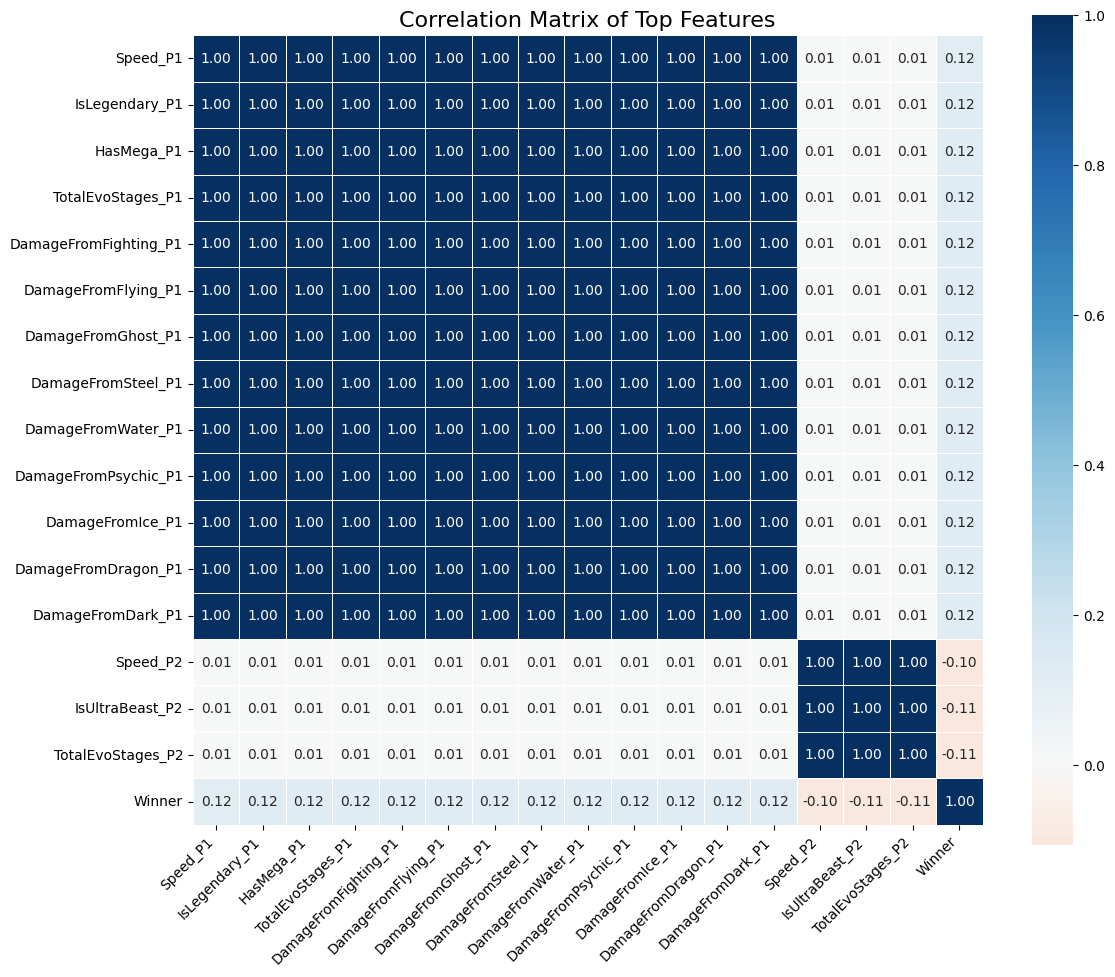

In [28]:
cols_to_plot = list(selected_cols[:16]) + ['Winner']

corr_matrix = df[cols_to_plot].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    annot=True,      
    fmt=".2f",        
    cmap='RdBu',  
    center=0,         
    linewidths=0.5,   
    square=True       
)

plt.title('Correlation Matrix of Top Features', fontsize=16)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

train = accuracy_score(y_train, y_train_pred)
test = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train * 100:.2f}%")
print(f"Test Accuracy: {test * 100:.2f}%")

Train Accuracy: 83.16%
Test Accuracy: 82.90%


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, f1_score, confusion_matrix
import time

def evaluate_model(model, X_test, y_test, model_name="Model"):
    # 1. Dự đoán nhãn và xác suất
    start_time = time.time()
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Lấy xác suất của lớp 1 (Winner)
    end_time = time.time()
    
    # 2. Tính các chỉ số
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    
    print(f"📊 EVALUATION {model_name.upper()}:")
    print(f"- Accuracy : {acc:.4f} ")
    print(f"- Log Loss : {ll:.4f} ")
    print(f"- ROC-AUC  : {auc:.4f} ")
    print(f"- F1-Score : {f1:.4f}")
    print(f"- Predict Time: {end_time - start_time:.4f}s")
    print("-" * 30)

evaluate_model(model, X_test, y_test, "Raw Data Model")

📊 EVALUATION RAW DATA MODEL:
- Accuracy : 0.8290 
- Log Loss : 0.4304 
- ROC-AUC  : 0.8905 
- F1-Score : 0.8395
- Predict Time: 0.0964s
------------------------------


25 biến được chọn: Index(['Speed_P1', 'IsLegendary_P1', 'HasMega_P1', 'TotalEvoStages_P1',
       'DamageFromFighting_P1', 'DamageFromFlying_P1', 'DamageFromGhost_P1',
       'DamageFromSteel_P1', 'DamageFromWater_P1', 'DamageFromPsychic_P1',
       'DamageFromIce_P1', 'DamageFromDragon_P1', 'DamageFromDark_P1',
       'Speed_P2', 'IsUltraBeast_P2', 'TotalEvoStages_P2',
       'DamageFromNormal_P2', 'DamageFromFighting_P2', 'DamageFromFlying_P2',
       'DamageFromPoison_P2', 'DamageFromBug_P2', 'DamageFromGhost_P2',
       'DamageFromFire_P2', 'DamageFromPsychic_P2', 'DamageFromDark_P2'],
      dtype='object')


C:\Users\HP\AppData\Local\Temp\ipykernel_17064\908049553.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


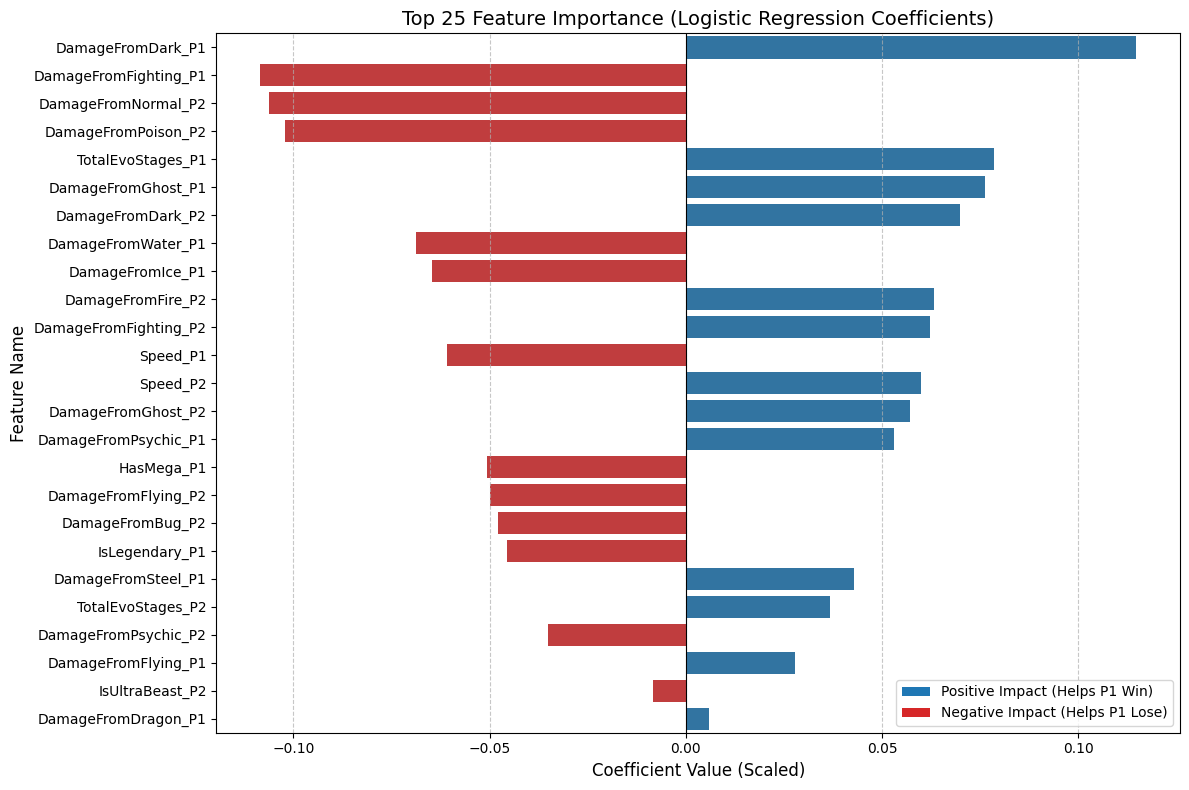

In [32]:
selector = RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=25, step=1)
selector.fit(X_train, y_train)

selected_cols = X_train.columns[selector.support_]
print(f"25 biến được chọn: {selected_cols}")

coeffs = selector.estimator_.coef_[0]

importance_df = pd.DataFrame({
    'Feature': selected_cols,
    'Importance': coeffs
})

importance_df['Abs_Importance'] = importance_df['Importance'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

plt.figure(figsize=(12, 8))

colors = ['#1f77b4' if x > 0 else '#d62728' for x in importance_df['Importance']]

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette=colors
)

plt.title('Top 25 Feature Importance (Logistic Regression Coefficients)', fontsize=14)
plt.xlabel('Coefficient Value (Scaled)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8) 
plt.grid(axis='x', linestyle='--', alpha=0.7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Positive Impact (Helps P1 Win)'),
                   Patch(facecolor='#d62728', label='Negative Impact (Helps P1 Lose)')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

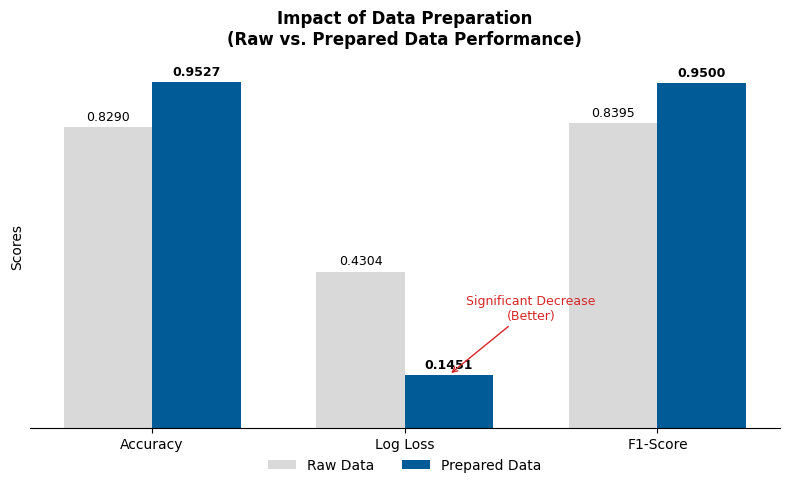

In [33]:
metrics = ['Accuracy', 'Log Loss', 'F1-Score']
raw_data = [0.8290, 0.4304, 0.8395]
prep_data = [0.9527 , 0.1451, 0.9500]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width/2, raw_data, width, label='Raw Data', color='#d9d9d9')
rects2 = ax.bar(x + width/2, prep_data, width, label='Prepared Data', color='#005b96')

ax.set_ylabel('Scores')
ax.set_title('Impact of Data Preparation\n(Raw vs. Prepared Data Performance)', 
             fontsize=12, fontweight='bold', pad=15) 
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.set_yticks([])

def autolabel(rects, is_prep=False):
    for rect in rects:
        height = rect.get_height()
        weight = 'bold' if is_prep else 'normal'
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9, fontweight=weight) # Smaller font for labels

autolabel(rects1, is_prep=False)
autolabel(rects2, is_prep=True)

ax.annotate('Significant Decrease\n(Better)',
            xy=(1 + width/2, 0.1459), xycoords='data',
            xytext=(1.5, 0.3), textcoords='data',
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color='#d62728'),
            color='#d62728', fontsize=9, ha='center')

plt.tight_layout()
plt.show()